In [1]:
import random
import sys
from typing import Any

import numpy as np
import torch
import wandb

from typing import Any

import numpy as np
import pandas as pd
import torch
import torchvision
import torch.nn.functional as F
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from matplotlib import pyplot as plt
from numpy.typing import NDArray
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torchvision.transforms import InterpolationMode
from ucimlrepo import fetch_ucirepo

from reboot.utils.enums import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import make_classification


sys.path.append("/workspaces/ReBoot/")
from torch.utils.data import DataLoader, TensorDataset

from reboot.models.backprop_models import BackpropMLP
from reboot.parser import get_parser_args
from reboot.utils.data import load_float_dataset
from reboot.utils.nn import accuracy
from reboot.utils.train import epoch_log, wandb_init

In [2]:
# Experiment config
dataset_config = dict(
    dataset="CROPPED_MNIST",
    subsample=None,
    resize=None,
    normalize=False,
    pad_data=False,
    pad_labels=False,
)

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


configs: dict[str, Any] = dataset_config

Loaded dataset: CROPPED_MNIST
Train set:  (60000, 1, 8, 8), (60000, 10)
Test set:   (10000, 1, 8, 8), (10000, 10)
Data types: (float32, float32)

Train data statistics:
 Min:  0.00000 - Max:  1.00000
Mean:  0.13257 - Std:  0.30051


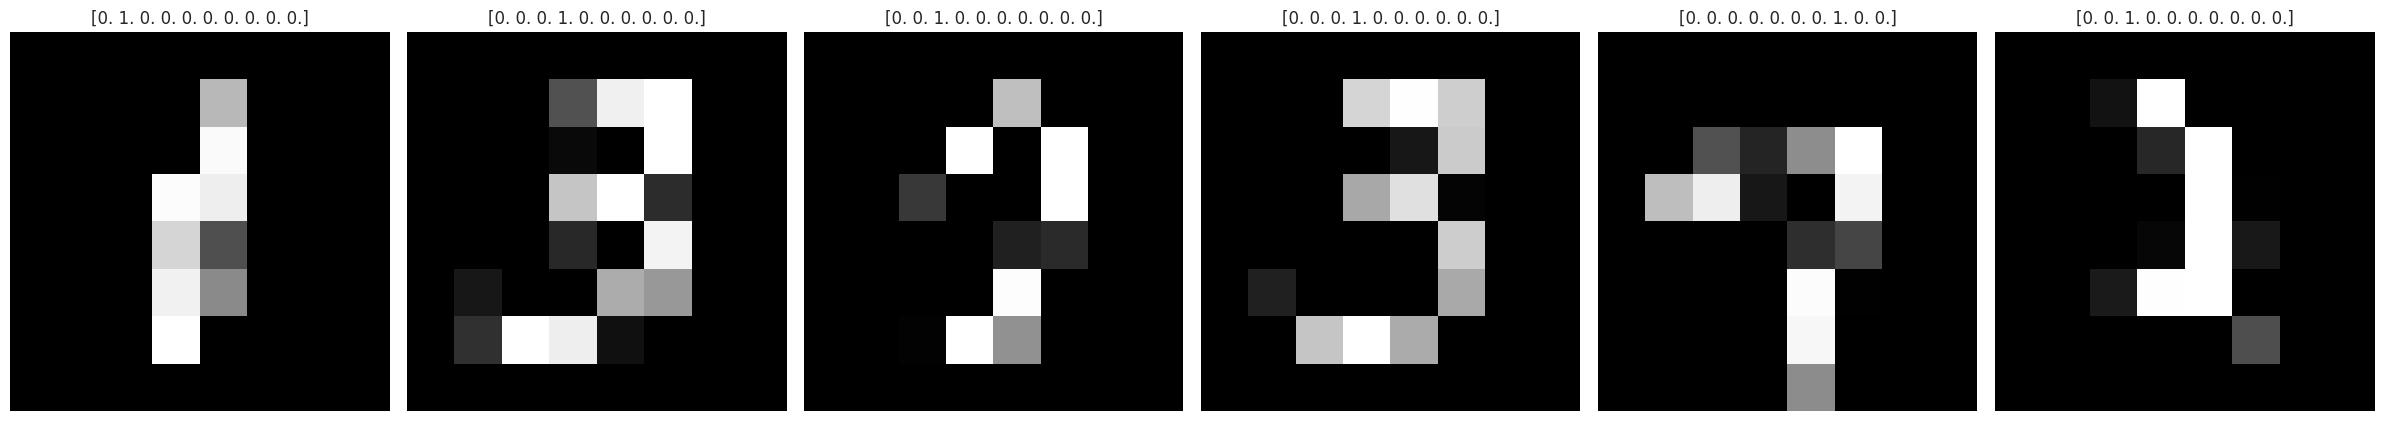

In [3]:
X_train, _, X_test, y_train, _, y_test = load_float_dataset(
    configs, show_images=True
)